In [1]:
import pandas as pd
import numpy as np



In [2]:

df = pd.read_csv("../data/processed/application_train_cleaned.csv")

df.head()

,Unnamed: 0,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,SK_ID_CURR
0,0,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,278621
1,1,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,139008
2,2,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,138348
3,3,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0,64140
4,4,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,219374


In [3]:
df["AGE"] = (-df["DAYS_BIRTH"]) / 365
df["YEARS_EMPLOYED"] = (-df["DAYS_EMPLOYED"]) / 365
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

df["YEARS_EMPLOYED"] = (-df["DAYS_EMPLOYED"]) / 365

In [4]:
df["CREDIT_INCOME_RATIO"] = (
    df["AMT_CREDIT"] /
    df["AMT_INCOME_TOTAL"]
)

In [5]:
df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] /
    df["AMT_INCOME_TOTAL"]
)

In [6]:
df["INCOME_PER_PERSON"] = (
    df["AMT_INCOME_TOTAL"] /
    df["CNT_FAM_MEMBERS"]
)

In [7]:
df["CREDIT_PER_PERSON"] = (
    df["AMT_CREDIT"] /
    df["CNT_FAM_MEMBERS"]
)

In [8]:
df["EMPLOYMENT_AGE_RATIO"] = (
    df["YEARS_EMPLOYED"] /
    df["AGE"]
)

In [9]:
df["CREDIT_GOODS_DIFF"] = (
    df["AMT_CREDIT"] -
    df["AMT_GOODS_PRICE"]
)

In [10]:
df["FAMILY_SIZE"] = pd.cut(
    df["CNT_FAM_MEMBERS"],
    bins=[0,2,4,20],
    labels=["Small","Medium","Large"]
)

In [11]:
new_features = [
    "AGE",
    "YEARS_EMPLOYED",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "INCOME_PER_PERSON",
    "CREDIT_PER_PERSON",
    "EMPLOYMENT_AGE_RATIO",
    "CREDIT_GOODS_DIFF"
]

df[new_features].head()

,AGE,YEARS_EMPLOYED,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,INCOME_PER_PERSON,CREDIT_PER_PERSON,EMPLOYMENT_AGE_RATIO,CREDIT_GOODS_DIFF
0,45.931507,3.254795,4.790750,0.132217,135000.0,646751.25,0.070862,164002.5
1,52.068493,8.326027,2.316167,0.219900,67500.0,156341.25,0.159905,15682.5
2,54.608219,8.323288,4.222222,0.179963,121500.0,513000.00,0.152418,0.0
3,46.413699,4.350685,4.954500,0.277955,49500.0,245247.75,0.093737,35995.5
4,51.643836,1.230137,4.250000,0.116875,180000.0,765000.00,0.023820,0.0


In [12]:
corr = df[new_features + ["TARGET"]].corr()

corr["TARGET"].sort_values(ascending=False)

TARGET                  1.000000
CREDIT_GOODS_DIFF       0.032615
ANNUITY_INCOME_RATIO    0.014518
CREDIT_INCOME_RATIO    -0.008514
INCOME_PER_PERSON      -0.014767
CREDIT_PER_PERSON      -0.024597
EMPLOYMENT_AGE_RATIO   -0.067189
YEARS_EMPLOYED         -0.074206
AGE                    -0.077633
Name: TARGET, dtype: float64

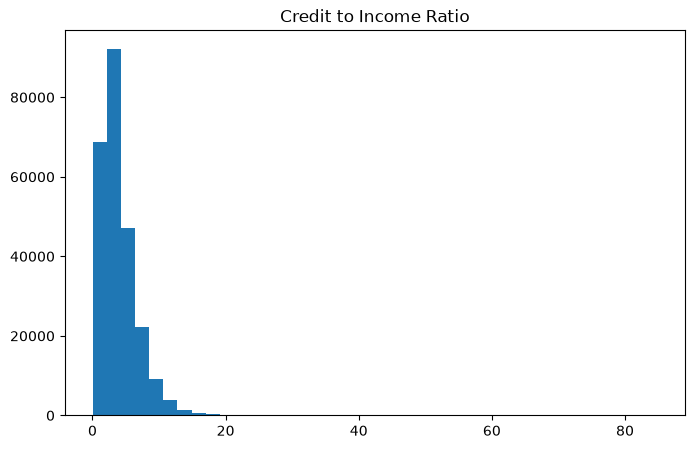

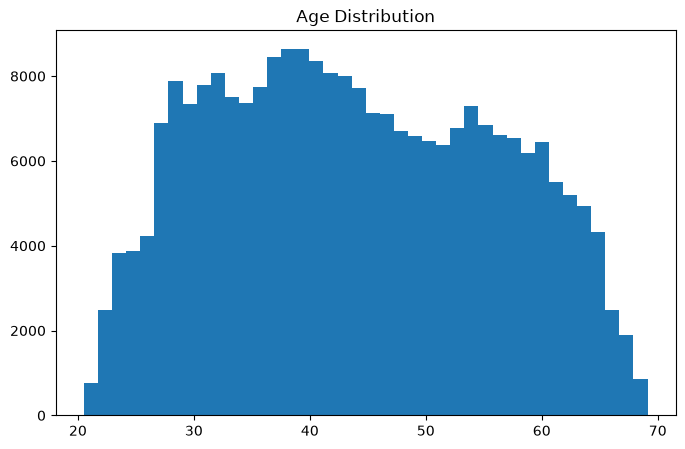

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["CREDIT_INCOME_RATIO"], bins=40)

plt.title("Credit to Income Ratio")

plt.show()
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["AGE"], bins=40)

plt.title("Age Distribution")

plt.show()

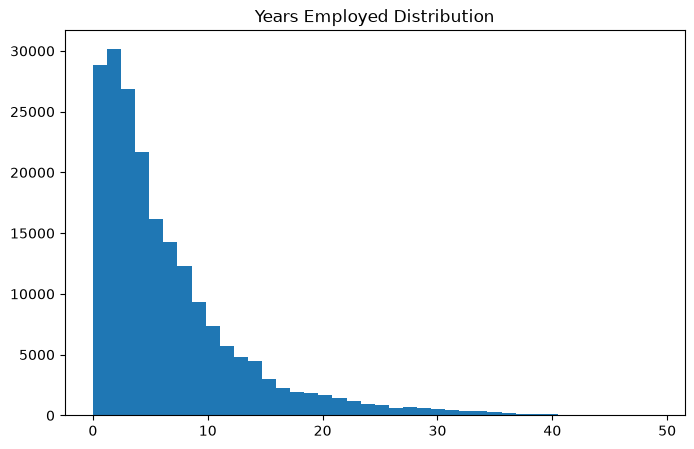

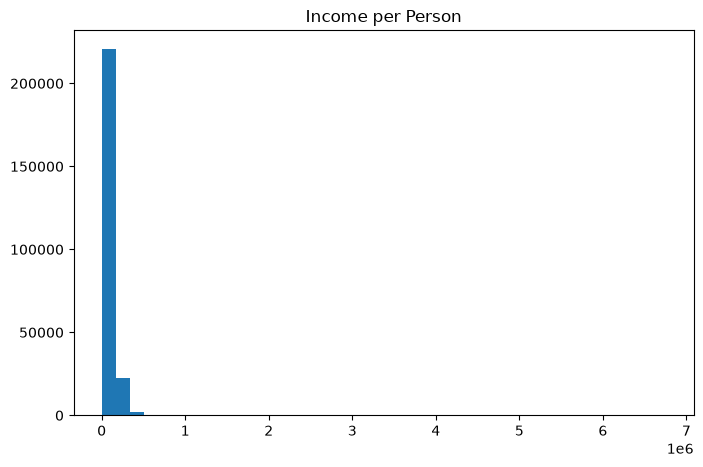

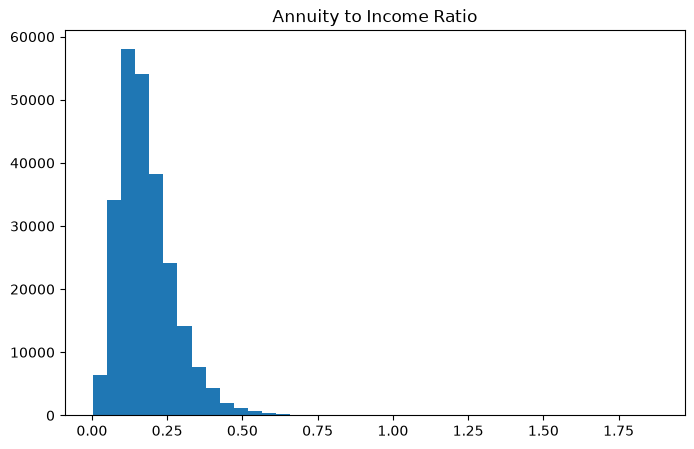

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["YEARS_EMPLOYED"], bins=40)

plt.title("Years Employed Distribution")

plt.show()
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["INCOME_PER_PERSON"], bins=40)

plt.title("Income per Person")

plt.show()
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["ANNUITY_INCOME_RATIO"], bins=40)

plt.title("Annuity to Income Ratio")

plt.show()

In [15]:
df.to_csv(
    "../data/processed/application_train_featured.csv",
    index=False
)